In [3]:
import jax.numpy as jnp
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
def generate_guassian_dist(mean, std, size, round_to:int=2):
    dist = np.random.normal(mean, std, size)
    return np.round(dist, round_to)

def generate_uniform_dist(low, high, size, round_to:int=2):
    dist = np.random.uniform(low, high, size)
    return np.round(dist, round_to)
    

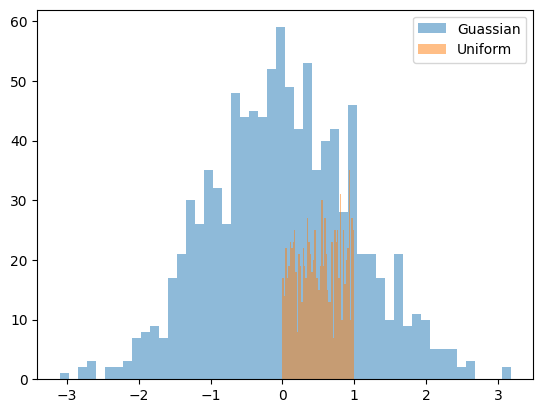

In [7]:
guassian = generate_guassian_dist(0, 1, 1000)
uniform = generate_uniform_dist(0, 1, 1000)

plt.hist(guassian, bins=50, alpha=0.5, label='Guassian')
plt.hist(uniform, bins=50, alpha=0.5, label='Uniform')
plt.legend()
plt.show()

In [29]:
# how to convert the guassian and uniform distributions to a token distribution?
import jax
list_g = [-0.78,  0.32, -0.36, -0.82]
tokens_g = []
vocab_items = [
    "guassian",
    "uniform",
    "mu",
    "sigma",
    "low",
    "high",
    "<pad>",
    "<bos>",   # beginning of sequence
    "<eos>",   # end of sequence, often useful
    "-",
    ".",
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
]
vocab = {token: idx for idx, token in enumerate(vocab_items)}
voca_tokens = jax.nn.one_hot(np.arange(0, len(vocab)), num_classes=len(vocab))
def tokenize_number(x, vocab, decimals=2):
    s = f"{x:.{decimals}f}"
    chars = ["<bos>"] + list(s) + ["<eos>"]
    return [vocab[c] for c in chars]

for x in list_g:
    idxs = tokenize_number(x, vocab)
    for idx in idxs:
        print(voca_tokens[idx])
    break 


[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
